# Application to approximation theory
In this first part, we consider a function $f:\mathbb R^n \rightarrow \mathbb R^q$ that is known only at a finite number of points $n_{data}$. The goal is to approximate $f$ away from those known points. 

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import Neural as Neur

# First application
Here $f$ is a map from $[0,1]$ to $\mathbb{R}$ given by
$x\mapsto \sin(6\pi |x|^{3/2}) +x^2$. The inputs $x_i$ are 256 points uniformly spaced on $[0,1]$, and the outputs are the 256 values $y_i=f(x_i)$. Store these in arrays `x` and `y` respectively.

In [2]:
x = np.linspace(0, 1, 256).reshape(1, -1)
y = np.sin(6 * np.pi * np.abs(x) ** 1.5) + x ** 2

The activation function we will use is
$$x\mapsto \frac{1}{1+e^{-x}}$$
Implement this activation and its derivative in the `Sigmoid` class.



In [3]:
import Neural as Neur
L=Neur.Sigmoid()
x2=np.array([0,3,2])
print(L.forward(x2))
print(L.backward(x2))
# You should get
# [0.5        0.95257413 0.88079708]
# (None, array([0.        , 0.13552998, 0.20998717]))

[0.5        0.95257413 0.88079708]
(None, array([0.        , 0.13552998, 0.20998717]))


# Approximation with a deep neural network
We build two neural networks. The first, denoted `N`, is a Dense layer $(1,12)$, followed by a sigmoid, then a Dense layer $(12,1)$. This network approximates our function $f$. We also build a network `N_a` consisting of `N` followed by an $L^2$ loss layer; use `N_a` for optimization. Create both networks and run fixed-step gradient descent with `N_a` for $2000$ iterations, tuning the step size (you will find this is nearly impossible by hand). Your algorithm should record the objective value across iterations. Also plot the true data and the network’s predictions.

In [4]:
np.random.seed(13)
N=Neur.Network([Neur.Dense(1,12),Neur.Sigmoid(),Neur.Dense(12,1)])
N_a=Neur.Network([N,Neur.Loss_L2(y)])


You are not expected to have found a good step size by hand. We therefore use the `BFGS` optimizer from `scipy`. If you define `func(u)` to return the cost and `nablafunc(u)` to return the gradient of `func`, you can run BFGS with:
`from scipy.optimize import minimize`
`res=minimize(func, u, method='BFGS', jac=nablafunc, options={'gtol': 1e-6, 'disp': True, 'maxiter': 2000})`
The object `res` contains many fields; the minimizer is in `res.x`.

In [5]:
np.random.seed(13)
N=Neur.Network([Neur.Dense(1,12),Neur.Sigmoid(),Neur.Dense(12,1)])
N_a=Neur.Network([N,Neur.Loss_L2(y)])


def func(u):
    N_a.set_params(u)
    return N_a.forward(x)

def nablafunc(u):
    N_a.set_params(u)
    N_a.forward(x)
    grad, _ = N_a.backward(None)
    return grad

u=N_a.get_params()
np.random.seed(42)
eps=1.e-4
c=func(u)
grad=nablafunc(u)
for i in range(4) :
    d=np.random.randn(u.shape[0])
    c2=func(u+eps*d)
    print((c2-c)/eps,np.dot(d,grad))

320.8762543664534 -570.4683420333622
-534.726641749188 827.8620060324613
494.8506062642366 284.0153362609458
389.602743111368 -63.18414353741065


         Current function value: 59.928634
         Iterations: 5
         Function evaluations: 50
         Gradient evaluations: 39


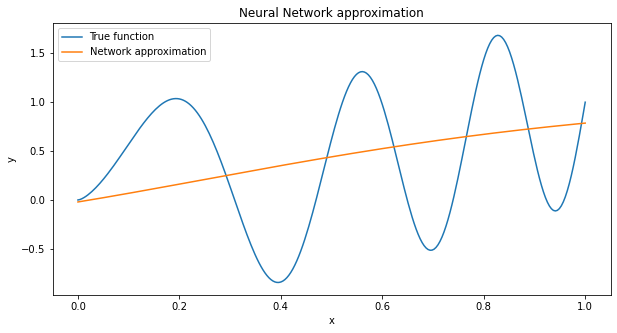

In [6]:
from scipy.optimize import minimize

np.random.seed(13)
N=Neur.Network([Neur.Dense(1,12),Neur.Sigmoid(),Neur.Dense(12,1)])
N_a=Neur.Network([N,Neur.Loss_L2(y)])

u0 = N_a.get_params()

res = minimize(func, u0, method='BFGS', jac=nablafunc, options={'gtol': 1e-6, 'disp': True, 'maxiter': 2000})

N_a.set_params(res.x)
y_pred = N.forward(x)

plt.figure(figsize=(10, 5))
plt.plot(x.ravel(), y.ravel(), label='True function')
plt.plot(x.ravel(), y_pred.ravel(), label='Network approximation')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Neural Network approximation')
plt.show()